# Selective Interference in Retrieved-Context Models

> A context-binding account of how competing events selectively impair recall of encoded experiences.

The selective interference paradigm explores why visuospatial tasks performed after viewing a trauma film selectively reduce intrusive memories without impairing recognition.
Existing accounts invoke dual traces, reconsolidation windows, or modality-specific disruption.
This notebook develops a single-system account using retrieved-context models (CMR and eCMR).

The central claim is that interference arises from *competitor encoding* in trauma-adjacent context.
The pattern of impairment depends on context overlap at encoding — temporal, emotional, or both.
Competitors that are strongly encoded in context similar to the original film events divert retrieval competition away from the film items, suppressing context-to-item recall while leaving item-to-context recognition structurally intact.

The notebook proceeds in three parts.
A **calibration** section establishes the paradigm: the trial sequence, filler events to suppress recency artefacts, and the delay/reminder mechanism that allows context reinstatement at a temporal remove.
**Simulations 1–2** explore the encoding story — what intensifies interference and how non-temporal context features (arousal) create selective vulnerability beyond temporal contiguity.
**Simulations 3–4** explore the retrieval story — how retrieval-control mechanisms modulate vulnerability and how test-phase cues can undermine that protection.
**Simulation 5** demonstrates an architectural implication: the recall/recognition dissociation emerges from the structural difference between context-to-item and item-to-context retrieval.

## Table of contents

- [Setup](#setup)
- [Fitting per-subject parameters](#fitting-per-subject-parameters)
  - [Parameter summary](#parameter-summary)
- [Trial function](#trial-function)
- [Calibration](#calibration)
  - [Calibrating break item count](#calibrating-break-item-count)
  - [Calibrating post-interference filler count](#calibrating-post-interference-filler-count)
  - [Pre-interference context state: break and reminder](#pre-interference-context-state-break-and-reminder)
  - [Baseline SPC](#baseline-spc)
- [Sim 1: Interference intensifiers](#sim-1-interference-intensifiers)
  - [Sweeping interference MCF learning rate](#sweeping-interference-mcf-learning-rate)
  - [Sweeping interference encoding drift rate](#sweeping-interference-encoding-drift-rate)
  - [Sweeping competitor count](#sweeping-competitor-count)
- [Sim 2: Arousal-specific interference](#sim-2-arousal-specific-interference)
- [Sim 3: Retrieval control](#sim-3-retrieval-control)
- [Sim 4: Cues at test](#sim-4-cues-at-test)
- [Sim 5: Mode dissociation](#sim-5-mode-dissociation)
- [General discussion](#general-discussion)

## Setup

In [1]:
import json
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import jit, lax, random, vmap
from jax.tree_util import tree_map
from typing import Optional

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.components.context import init as init_context
from jaxcmr.components.linear_memory import init_mcf, init_mfc
from jaxcmr.components.termination import PositionalTermination
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.models.cmr import CMR, make_factory
from jaxcmr.selective_interference.plotting import (
    plot_interference_spc,
    plot_summary_dv,
)
from jaxcmr.simulation import simulate_free_recall

warnings.filterwarnings("ignore")



In [2]:
# --- paradigm constants ---
N_FILM = 16
N_BREAK_DEFAULT = 16
N_BREAK_MAX = 32
M_DEFAULT = 16
M_MAX = 32
N_FILLER_DEFAULT = 16
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100
FILM_RECALLED_YLIM: Optional[list[float]] = None  # tuple to fix y-axis, None to auto-scale
SHOW_BREAK_IN_SPC = False  # show break items in SPC sweep plots
SHOW_FILLERS_IN_SPC = False  # show filler items in SPC sweep plots
N_BREAK_SHOWN = N_BREAK_DEFAULT if SHOW_BREAK_IN_SPC else 0

# --- model tier definitions ---
# Standard tier: all phases at default counts (smallest matrices)
STD_LIST_LENGTH = N_FILM + N_BREAK_DEFAULT + M_DEFAULT + N_FILLER_DEFAULT    # 64
# Extended tier: one phase at max count (for count sweeps)
EXT_LIST_LENGTH = N_FILM + N_BREAK_DEFAULT + M_MAX + N_FILLER_DEFAULT        # 80
BRK_LIST_LENGTH = N_FILM + N_BREAK_MAX + M_DEFAULT + N_FILLER_DEFAULT        # 80
FEXT_LIST_LENGTH = N_FILM + N_BREAK_DEFAULT + M_DEFAULT + N_FILLER_MAX       # 80
# Maximum recall steps (subjects recall << 64 items; generous upper bound)
MAX_RECALL = 48

# Keep LIST_LENGTH for backward compat (= largest tier)
LIST_LENGTH = N_FILM + N_BREAK_MAX + M_MAX + N_FILLER_MAX  # 112, used only by remap display

# --- derived display constants ---
BASELINE_MCF_SCALE = 1.0
STD_PRESENTED = (
    (N_BREAK_DEFAULT if SHOW_BREAK_IN_SPC else 0)
    + N_FILM + M_DEFAULT
    + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)
)
DEFAULT_PRESENTED = STD_PRESENTED  # backward compat alias

# --- fitted parameter scale factors (multiply per-subject values) ---
FITTED_PARAM_SCALES = {
    "encoding_drift_rate": 1.0,
    "start_drift_rate": 1.0,
    "recall_drift_rate": 1.0,
    "shared_support": 1.0,  # low: reduces pre-experimental cross-position MCF interference
    "item_support": 1.0,
    "learning_rate": 1.0,
    "primacy_scale": 1.0,
    "primacy_decay": 1.0,
    "choice_sensitivity": 1.0,
    "stop_probability_scale": 0.57,
    "stop_probability_growth": 1.0,
}

# --- default scale factors for non-swept phases ---
DEFAULT_BREAK_DRIFT_SCALE = 1.0
DEFAULT_BREAK_MCF_SCALE = 1.0
DEFAULT_REMINDER_START_DRIFT_SCALE = 4.0  # high: approximates hard reset to start-of-list
DEFAULT_REMINDER_DRIFT_SCALE = 0.3  # low relative to encoding drift rate
DEFAULT_FILLER_DRIFT_SCALE = 1.0
DEFAULT_FILLER_MCF_SCALE = 1.0

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 1
RUN_TAG = f"best_of_{BEST_OF}"
REDO_FITS = False

# --- paths ---
project_root = Path(find_project_root())
fit_dir = Path("results/fits")
fit_dir.mkdir(parents=True, exist_ok=True)
fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

# --- data ---
data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)

# --- model factory (for fitting only) ---
model_factory = make_factory(init_mfc, init_mcf, init_context, PositionalTermination)

rng = random.PRNGKey(SEED)


## Fitting per-subject parameters

We fit CMR to each subject's free-recall data from Healey & Kahana (2014) — a 16-item word-list experiment that maps directly onto our 16-item film list. The model variant uses `PositionalTermination`: stop probability grows exponentially with the number of items already recalled (`scale * exp(position * growth)`), giving the model a realistic tendency to terminate recall before exhausting the pool. The loss function (`MemorySearchLikelihoodFnGenerator`) evaluates the full recall sequence including the termination event, so the optimizer jointly fits recall order and stopping behaviour.

Eleven free parameters are fitted per subject: `encoding_drift_rate`, `start_drift_rate`, `recall_drift_rate`, `shared_support`, `item_support`, `learning_rate` (MFC), `primacy_scale`, `primacy_decay`, `choice_sensitivity`, `stop_probability_scale`, and `stop_probability_growth`. Differential evolution (`ScipyDE`) runs 1000 generations with a population of 15 and takes the best of 3 independent runs.

Fitted parameters are cached to disk. On subsequent runs, the fitting cell loads from cache unless `REDO_FITS` is set to `True`.

In [3]:
if fit_path.exists() and not REDO_FITS:
    with fit_path.open() as f:
        results = json.load(f)
    print(f"Loaded fits from {fit_path}")
else:
    from jaxcmr.fitting import ScipyDE
    from jaxcmr.loss.sequence_likelihood import MemorySearchLikelihoodFnGenerator

    fixed = {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
    }
    free_bounds = {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        "stop_probability_scale": [2.22e-16, 5.0],
        "stop_probability_growth": [2.22e-16, 10.0],
    }
    fitter = ScipyDE(
        data,
        None,
        fixed,
        model_factory,
        MemorySearchLikelihoodFnGenerator,
        hyperparams={
            "bounds": free_bounds,
            "num_steps": 200,
            "pop_size": 15,
            "relative_tolerance": 0.001,
            "cross_over_rate": 0.9,
            "diff_w": 0.85,
            "best_of": BEST_OF,
            "progress_bar": True,
        },
    )
    results = fitter.fit(trial_mask)
    with fit_path.open("w") as f:
        json.dump(results, f, indent=4)
    print(f"Fitted and saved to {fit_path}")

params = {key: jnp.array(val) for key, val in results["fits"].items()}

# Natural upper bounds for parameters where the math requires it
# (drift rates use sqrt(1 - drift^2); learning_rate is also a drift rate in MFC)
_PARAM_UPPER_BOUNDS = {
    "encoding_drift_rate": 1.0,
    "start_drift_rate": 1.0,
    "recall_drift_rate": 1.0,
    "learning_rate": 1.0,
}

# Apply per-parameter scale factors, clipping to natural bounds
for name, scale in FITTED_PARAM_SCALES.items():
    if scale != 1.0:
        params[name] = params[name] * scale
        if name in _PARAM_UPPER_BOUNDS:
            hi = _PARAM_UPPER_BOUNDS[name]
            n_clipped = int(jnp.sum(params[name] > hi))
            params[name] = jnp.clip(params[name], 0.0, hi)
            clip_msg = f" (clipped {n_clipped} subjects)" if n_clipped else ""
            print(f"  Scaled {name} by {scale}{clip_msg}")
        else:
            print(f"  Scaled {name} by {scale}")

n_subjects = len(params["encoding_drift_rate"])
median_idx = n_subjects // 2
print(f"{n_subjects} subjects")

Loaded fits from results/fits/HealeyKahana2014_WeirdCMRPosStop_best_of_1.json
  Scaled stop_probability_scale by 0.57
126 subjects


### Parameter summary

The table below shows the distribution of fitted values across subjects. These are the parameters that govern film-phase encoding — the interference phase will use different values for `encoding_drift_rate` and the MCF learning rate, while leaving everything else at the fitted values.

In [4]:
free_params = [
    "encoding_drift_rate",
    "start_drift_rate",
    "recall_drift_rate",
    "shared_support",
    "item_support",
    "learning_rate",
    "primacy_scale",
    "primacy_decay",
    "choice_sensitivity",
    "stop_probability_scale",
    "stop_probability_growth",
]

print(f"{'Parameter':>25s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
print("-" * 65)
for name in free_params:
    vals = np.array(params[name])
    print(
        f"{name:>25s}  {vals.mean():8.4f}  {vals.std():8.4f}  {vals.min():8.4f}  {vals.max():8.4f}"
    )

                Parameter      Mean       Std       Min       Max
-----------------------------------------------------------------
      encoding_drift_rate    0.7702    0.1475    0.0294    0.9833
         start_drift_rate    0.2017    0.2199    0.0012    0.9362
        recall_drift_rate    0.8476    0.1150    0.4489    0.9976
           shared_support   19.5325   22.7464    0.0880   99.9017
             item_support   30.2362   29.0810    0.2694   99.8182
            learning_rate    0.2960    0.2288    0.0075    0.9637
            primacy_scale   17.7227   23.6121    0.2289   98.5164
            primacy_decay   23.5531   30.8395    0.0001   92.6645
       choice_sensitivity   46.9343   32.8021    1.2412   99.9499
   stop_probability_scale    0.0045    0.0057    0.0000    0.0333
  stop_probability_growth    0.3721    0.0902    0.1142    0.6394


## Trial function

The computation is split into a **cached phase** (`prepare_all_subjects`) that encodes film items, encodes break items (modeling the retention interval), reinstates start-of-list context, and runs the reminder for each subject, and a **variable phase** (`batched_sweep`) that encodes interference and filler items with sweep-specific parameters and runs free recall. The cached phase depends on `break_drift_scale`, `break_mcf_scale`, `reminder_start_drift_scale`, and `reminder_drift_scale`; the variable phase depends on `interference_drift_scale`, `interference_mcf_scale`, and the filler/interference item arrays.

In [5]:
# =====================================================================
# Tier-specific item arrays
# =====================================================================

# --- Standard tier (LIST_LENGTH=64) ---
STD_FILM = jnp.arange(1, N_FILM + 1)                                          # 1-16
STD_BREAK_ALL = jnp.arange(N_FILM + 1, N_FILM + N_BREAK_DEFAULT + 1)          # 17-32
STD_INTERF = jnp.arange(N_FILM + N_BREAK_DEFAULT + 1,
                         N_FILM + N_BREAK_DEFAULT + M_DEFAULT + 1)             # 33-48
STD_FILLER = jnp.arange(N_FILM + N_BREAK_DEFAULT + M_DEFAULT + 1,
                         STD_LIST_LENGTH + 1)                                  # 49-64

# --- Interference-extended tier (LIST_LENGTH=80, interf up to 32) ---
EXT_INTERF_ALL = jnp.arange(N_FILM + N_BREAK_DEFAULT + 1,
                             N_FILM + N_BREAK_DEFAULT + M_MAX + 1)             # 33-64
EXT_FILLER = jnp.arange(N_FILM + N_BREAK_DEFAULT + M_MAX + 1,
                         EXT_LIST_LENGTH + 1)                                  # 65-80

# --- Filler-extended tier (LIST_LENGTH=80, filler up to 32) ---
FEXT_INTERF = jnp.arange(N_FILM + N_BREAK_DEFAULT + 1,
                          N_FILM + N_BREAK_DEFAULT + M_DEFAULT + 1)            # 33-48
FEXT_FILLER_ALL = jnp.arange(N_FILM + N_BREAK_DEFAULT + M_DEFAULT + 1,
                              N_FILM + N_BREAK_DEFAULT + M_DEFAULT + N_FILLER_MAX + 1)  # 49-80

# --- Break-extended tier (LIST_LENGTH=80, break up to 32) ---
BRK_BREAK_ALL = jnp.arange(N_FILM + 1, N_FILM + N_BREAK_MAX + 1)             # 17-48
BRK_INTERF = jnp.arange(N_FILM + N_BREAK_MAX + 1,
                         N_FILM + N_BREAK_MAX + M_DEFAULT + 1)                 # 49-64
BRK_FILLER = jnp.arange(N_FILM + N_BREAK_MAX + M_DEFAULT + 1,
                         BRK_LIST_LENGTH + 1)                                  # 65-80


def make_ext_interf(m):
    """Zero-padded interference items for interference-extended tier."""
    return jnp.where(jnp.arange(M_MAX) < m, EXT_INTERF_ALL, 0)


def make_fext_filler(n):
    """Zero-padded filler items for filler-extended tier."""
    return jnp.where(jnp.arange(N_FILLER_MAX) < n, FEXT_FILLER_ALL, 0)


def make_brk_break(n):
    """Zero-padded break items for break-extended tier."""
    return jnp.where(jnp.arange(N_BREAK_MAX) < n, BRK_BREAK_ALL, 0)


# =====================================================================
# Model preparation and simulation
# =====================================================================

def prepare_single_subject(subject_idx, params, film_items, break_items,
                           break_drift_scale, break_mcf_scale,
                           reminder_start_drift_scale, reminder_drift_scale,
                           list_length):
    """Create model, encode film + break, reinstate start-of-list, run reminder."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        list_length,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    original_drift = model.encoding_drift_rate
    original_mcf_lr = model._mcf_learning_rate

    # Film encoding
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # Break encoding (models retention interval between film and reminder)
    break_drift = jnp.clip(break_drift_scale * original_drift, 0.0, 1.0)
    model = model.replace(
        encoding_drift_rate=break_drift,
        _mcf_learning_rate=break_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, break_items.size, lambda i, m: m.experience(break_items[i]), model
    )
    model = model.replace(
        encoding_drift_rate=original_drift,
        _mcf_learning_rate=original_mcf_lr,
    )

    # Start-of-list reinstatement (part of reminder mechanism)
    start_drift = jnp.clip(
        reminder_start_drift_scale * model.start_drift_rate, 0.0, 1.0
    )
    model = model.replace(
        context=model.context.integrate(model.context.initial_state, start_drift)
    )

    # Reminder (reinstate film context without learning)
    reminder_drift = jnp.clip(reminder_drift_scale * original_drift, 0.0, 1.0)

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)
    return model


prepare_all_subjects = jit(
    vmap(prepare_single_subject,
         in_axes=(0, None, None, None, None, None, None, None, None)),
    static_argnums=(8,),  # list_length must be static for CMR constructor
)


def run_from_cache(
    cached_model, rng, interference_items, filler_items,
    interference_drift_scale, interference_mcf_scale,
    filler_drift_scale, filler_mcf_scale,
    start_drift_scale, tau_scale,
):
    """From cached post-reminder state: encode interference + fillers, recall."""
    original_drift = cached_model.encoding_drift_rate
    original_mcf_lr = cached_model._mcf_learning_rate

    # Interference
    interference_drift = jnp.clip(
        interference_drift_scale * original_drift, 0.0, 1.0
    )
    model = cached_model.replace(
        encoding_drift_rate=interference_drift,
        _mcf_learning_rate=interference_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, interference_items.size,
        lambda i, m: m.experience(interference_items[i]), model,
    )

    # Filler
    filler_drift = jnp.clip(filler_drift_scale * original_drift, 0.0, 1.0)
    model = model.replace(
        encoding_drift_rate=filler_drift,
        _mcf_learning_rate=filler_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, filler_items.size,
        lambda i, m: m.experience(filler_items[i]), model,
    )

    # Recall — apply retrieval-control scales
    scaled_start_drift = jnp.clip(
        start_drift_scale * cached_model.start_drift_rate, 0.0, 1.0
    )
    model = model.replace(
        start_drift_rate=scaled_start_drift,
        mcf_sensitivity=tau_scale * cached_model.mcf_sensitivity,
    )
    model = model.start_retrieving()
    _, recalls = simulate_free_recall(model, MAX_RECALL, rng)
    return recalls


# Inner vmap: over replications (shared model, different RNGs)
# Outer vmap: over subjects (different cached models, different RNG blocks)
batched_sweep = jit(vmap(vmap(
    run_from_cache,
    in_axes=(None, 0, None, None, None, None, None, None, None, None),
), in_axes=(0, 0, None, None, None, None, None, None, None, None)))


def sweep_rngs(rng):
    """Per-subject, per-replication RNGs shaped (n_subjects, EXPERIMENT_COUNT, 2)."""
    rng, sub_rng = random.split(rng)
    rngs = random.split(sub_rng, n_subjects * EXPERIMENT_COUNT)
    return rngs.reshape(n_subjects, EXPERIMENT_COUNT, -1), rng


# =====================================================================
# Remap / SPC helpers (tier-parameterized)
# =====================================================================

def remap_recalls(recalls, n_break, n_interf, *, n_break_slots, n_interf_slots):
    """Close item-ID gaps for contiguous SPC positions.

    When SHOW_BREAK_IN_SPC is False, the entire break block is collapsed
    and break recalls are masked to 0.  When True, only the zero-padding
    gap within the break block is closed.  The interference zero-padding
    gap is always closed.
    """
    break_id_lo = N_FILM + 1
    break_id_hi = N_FILM + n_break_slots
    interf_id_start = N_FILM + n_break_slots + 1
    filler_id_start = N_FILM + n_break_slots + n_interf_slots + 1

    if SHOW_BREAK_IN_SPC:
        break_gap = n_break_slots - n_break
    else:
        recalls = jnp.where(
            (recalls >= break_id_lo) & (recalls <= break_id_hi), 0, recalls
        )
        break_gap = n_break_slots

    interf_gap = n_interf_slots - n_interf
    shift = jnp.where(
        recalls >= filler_id_start, break_gap + interf_gap,
        jnp.where(recalls >= interf_id_start, break_gap, 0),
    )
    return recalls - shift


def std_remap(recalls, n_break=N_BREAK_DEFAULT, n_interf=M_DEFAULT):
    """Remap for standard tier (break_slots=N_BREAK_DEFAULT, interf_slots=M_DEFAULT)."""
    return remap_recalls(recalls, n_break, n_interf,
                         n_break_slots=N_BREAK_DEFAULT, n_interf_slots=M_DEFAULT)


def ext_remap(recalls, n_break=N_BREAK_DEFAULT, n_interf=M_DEFAULT):
    """Remap for interference-extended tier (interf_slots=M_MAX)."""
    return remap_recalls(recalls, n_break, n_interf,
                         n_break_slots=N_BREAK_DEFAULT, n_interf_slots=M_MAX)


def fext_remap(recalls, n_break=N_BREAK_DEFAULT, n_interf=M_DEFAULT):
    """Remap for filler-extended tier (interf_slots=M_DEFAULT, filler up to 32)."""
    return remap_recalls(recalls, n_break, n_interf,
                         n_break_slots=N_BREAK_DEFAULT, n_interf_slots=M_DEFAULT)


def brk_remap(recalls, n_break=N_BREAK_DEFAULT, n_interf=M_DEFAULT):
    """Remap for break-extended tier (break_slots=N_BREAK_MAX)."""
    return remap_recalls(recalls, n_break, n_interf,
                         n_break_slots=N_BREAK_MAX, n_interf_slots=M_DEFAULT)


# =====================================================================
# Film recalled stats
# =====================================================================

def film_recalled_stats(recalls):
    """Mean and 95% CI of film items recalled (per-subject aggregation)."""
    film_mask = (recalls >= 1) & (recalls <= N_FILM)
    per_trial = jnp.sum(film_mask, axis=1).astype(float)
    per_sub = per_trial.reshape(n_subjects, EXPERIMENT_COUNT)
    sub_means = jnp.mean(per_sub, axis=1)
    mu = float(jnp.mean(sub_means))
    se = float(jnp.std(sub_means) / jnp.sqrt(n_subjects))
    return mu, mu - 1.96 * se, mu + 1.96 * se


# =====================================================================
# Sweep + plot helpers
# =====================================================================

_SWEEP_ARG_NAMES = [
    'interference_items', 'filler_items',
    'interference_drift_scale', 'interference_mcf_scale',
    'filler_drift_scale', 'filler_mcf_scale',
    'start_drift_scale', 'tau_scale',
]


def _std_sweep_defaults():
    return dict(
        interference_items=STD_INTERF,
        filler_items=STD_FILLER,
        interference_drift_scale=jnp.float32(1.0),
        interference_mcf_scale=jnp.float32(1.0),
        filler_drift_scale=jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
        filler_mcf_scale=jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        start_drift_scale=jnp.float32(1.0),
        tau_scale=jnp.float32(1.0),
    )


def run_sweep(cached_models, rng, sweep_values, swept_param, *,
              overrides=None, remap_fn=std_remap, n_presented=None):
    """Parameter sweep -> (spcs, stats, rng)."""
    if n_presented is None:
        n_presented = STD_PRESENTED
    args = _std_sweep_defaults()
    if overrides:
        args.update(overrides)

    spcs, stats = [], []
    for val in sweep_values:
        rngs_2d, rng = sweep_rngs(rng)
        args[swept_param] = jnp.float32(val)
        ordered = [args[k] for k in _SWEEP_ARG_NAMES]
        recalls_3d = batched_sweep(cached_models, rngs_2d, *ordered)
        recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
        recalls = remap_fn(recalls)
        spcs.append(fixed_pres_spc(recalls, n_presented))
        stats.append(film_recalled_stats(recalls))
    return spcs, stats, rng


def plot_sweep(spcs, stats, sweep_values, *,
               xlabel, sweep_title=None,
               labels=None, fmt="{:.2f}",
               n_break=N_BREAK_SHOWN, n_presented=None,
               n_interf=M_DEFAULT, n_filler=N_FILLER_DEFAULT,
               film_recalled_ylim=FILM_RECALLED_YLIM):
    """Two-panel figure: SPC (left) + film-recalled DV (right)."""
    if n_presented is None:
        n_presented = STD_PRESENTED
    if labels is None:
        labels = [fmt.format(v) for v in sweep_values]
    means, ci_lo, ci_hi = zip(*stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_interference_spc(spcs, labels, N_FILM, n_break=n_break, ax=axes[0])
    add_filler_boundary(axes[0], n_interf, n_filler, n_presented)
    if sweep_title:
        axes[0].set_title(sweep_title, fontsize=16)

    plot_summary_dv(sweep_values, means, ci_lo, ci_hi,
                    xlabel=xlabel, ax=axes[1])
    axes[1].set_title("Film Items Recalled", fontsize=16)
    if film_recalled_ylim is not None:
        axes[1].set_ylim(*film_recalled_ylim)
    plt.tight_layout()
    plt.show()
    return fig


# =====================================================================
# Filler boundary helper
# =====================================================================

def add_filler_boundary(ax, n_interf, n_filler, list_length, n_break=None):
    """Add filler zone boundary and relabel zones on an SPC axes."""
    if not SHOW_FILLERS_IN_SPC or n_filler <= 0:
        return
    n_break_shown = n_break if n_break is not None else (N_BREAK_DEFAULT if SHOW_BREAK_IN_SPC else 0)
    filler_start = N_FILM + n_break_shown + n_interf + 0.5
    ax.axvline(x=filler_start, color="blue", linewidth=1.5, linestyle=":", alpha=0.7)
    for txt in list(ax.texts):
        txt.remove()
    film_end_frac = (N_FILM + 0.5) / list_length
    filler_start_frac = filler_start / list_length
    film_x = film_end_frac / 2
    filler_x = (filler_start_frac + 1) / 2
    if n_break_shown > 0:
        break_end_frac = (N_FILM + n_break_shown + 0.5) / list_length
        break_x = (film_end_frac + break_end_frac) / 2
        interf_x = (break_end_frac + filler_start_frac) / 2
        ax.text(film_x, 0.97, "Film", ha="center", va="top",
                fontsize=12, fontweight="bold", transform=ax.transAxes)
        ax.text(break_x, 0.97, "Break", ha="center", va="top",
                fontsize=12, fontweight="bold", color="gray",
                transform=ax.transAxes)
        ax.text(interf_x, 0.97, "Interference", ha="center", va="top",
                fontsize=12, fontweight="bold", color="red",
                transform=ax.transAxes)
    else:
        interf_x = (film_end_frac + filler_start_frac) / 2
        ax.text(film_x, 0.97, "Film", ha="center", va="top",
                fontsize=12, fontweight="bold", transform=ax.transAxes)
        ax.text(interf_x, 0.97, "Interference", ha="center", va="top",
                fontsize=12, fontweight="bold", color="red",
                transform=ax.transAxes)
    ax.text(filler_x, 0.97, "Filler", ha="center", va="top",
            fontsize=12, fontweight="bold", color="blue", transform=ax.transAxes)


In [6]:
%%time
# Standard tier (LIST_LENGTH=64) — used by most sweeps
std_cached = prepare_all_subjects(
    jnp.arange(n_subjects), params, STD_FILM, STD_BREAK_ALL,
    jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
    jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE),
    jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
    STD_LIST_LENGTH,
)
cached_models = std_cached  # backward compat alias
print(f"Standard tier: cached {n_subjects} subjects (LIST_LENGTH={STD_LIST_LENGTH})")

# Extended tier (LIST_LENGTH=80) — used by competitor/filler count sweeps
ext_cached = prepare_all_subjects(
    jnp.arange(n_subjects), params, STD_FILM, STD_BREAK_ALL,
    jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
    jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE),
    jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
    EXT_LIST_LENGTH,
)
print(f"Extended tier: cached {n_subjects} subjects (LIST_LENGTH={EXT_LIST_LENGTH})")


Standard tier: cached 126 subjects (LIST_LENGTH=64)
Extended tier: cached 126 subjects (LIST_LENGTH=80)
CPU times: user 1.23 s, sys: 87.7 ms, total: 1.32 s
Wall time: 573 ms


## Calibration

The full trial sequence mirrors the experimental procedure: film encoding, break items that model the retention interval, start-of-list reinstatement followed by a reminder that reinstates film context, interference encoding, filler events that suppress recency artefacts, and free recall.
Each component is necessary for the paradigm to isolate context-overlap interference from mere recency effects.
This section calibrates each component and establishes a baseline.

### Calibrating break item count

Break items model the structured break between film viewing and the intervention (e.g., mood questionnaire, filler tasks).
They push context away from the film region via normal encoding, creating a temporal gap that the reminder must bridge.
More break items means more context drift away from film, increasing the need for the reminder to reinstate film context before interference encoding.

This sweep varies the number of break items from 0 to 32.
At 0 break items, context stays at end-of-film and the reminder has little work to do.
At higher counts, context drifts progressively further from the film region.
Break encoding uses the subject's fitted parameters at their default scale.

In [7]:
break_count_values = np.arange(0, N_BREAK_MAX + 1, 4)
print(f"Break count sweep values: {break_count_values}")

BREAK_SWEEP_PRESENTED = (
    N_FILM
    + (N_BREAK_MAX if SHOW_BREAK_IN_SPC else 0)
    + M_DEFAULT
    + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)
)

sweep_break_spcs = []
sweep_break_stats = []

for n_brk in break_count_values:
    cached_brk = prepare_all_subjects(
        jnp.arange(n_subjects), params, STD_FILM, make_brk_break(int(n_brk)),
        jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
        jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE),
        jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
        BRK_LIST_LENGTH,
    )
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_brk, rngs_2d,
        BRK_INTERF, BRK_FILLER,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(1.0), jnp.float32(1.0),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = brk_remap(recalls, n_break=N_BREAK_MAX, n_interf=M_DEFAULT)
    sweep_break_spcs.append(fixed_pres_spc(recalls, BREAK_SWEEP_PRESENTED))
    sweep_break_stats.append(film_recalled_stats(recalls))

print("Break count sweep done")


Break count sweep values: [ 0  4  8 12 16 20 24 28 32]
Break count sweep done


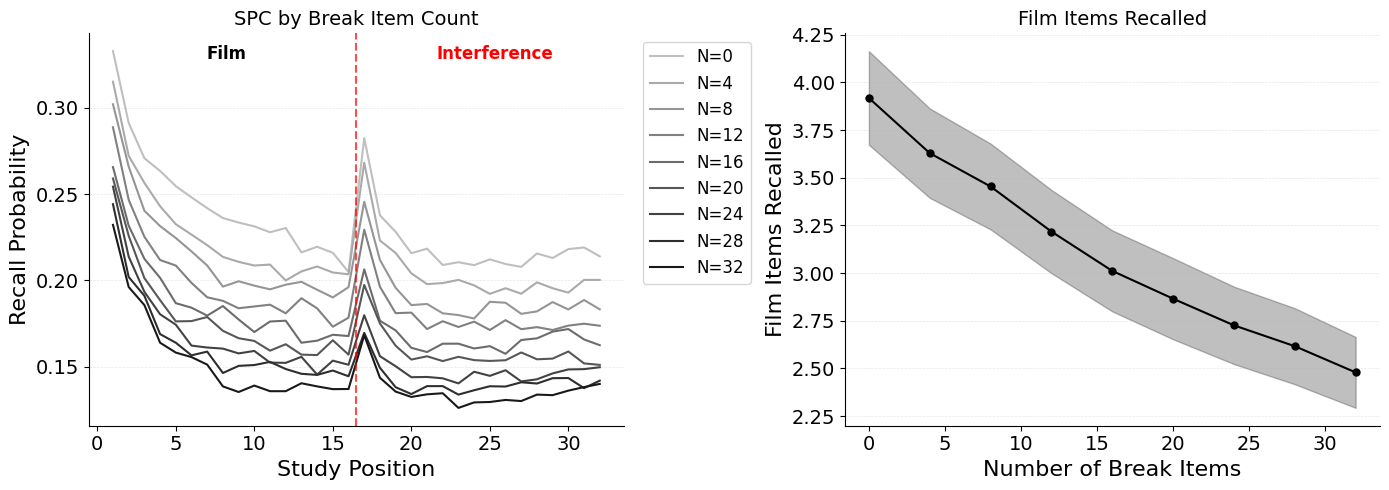

In [8]:
labels = [f"N={n}" for n in break_count_values]
means, ci_lo, ci_hi = zip(*sweep_break_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_break_spcs, labels, N_FILM,
                      n_break=N_BREAK_MAX if SHOW_BREAK_IN_SPC else 0,
                      ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, BREAK_SWEEP_PRESENTED,
                    n_break=N_BREAK_MAX if SHOW_BREAK_IN_SPC else None)
axes[0].set_title("SPC by Break Item Count", fontsize=14)

plot_summary_dv(
    break_count_values, means, ci_lo, ci_hi,
    xlabel="Number of Break Items", ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

### Calibrating post-interference filler count

Without filler events between interference encoding and recall, interference items benefit from a strong recency advantage — they were the most recently encoded items, so their context states are maximally similar to the retrieval probe at test onset.
Filler items simulate everyday events between the interference task and the recall test.
By encoding additional items after the interference phase, fillers push interference items out of the recency window, forcing any remaining interference to arise from contextual overlap with the film region rather than temporal proximity.

This sweep varies the number of post-interference filler items from 0 to 32 to determine how many are needed.
Filler encoding uses the subject's fitted parameters at their default scale.

In [9]:
filler_count_values = np.arange(0, N_FILLER_MAX + 1, 4)
print(f"Filler count sweep values: {filler_count_values}")

FILLER_PRESENTED_WITH = (
    N_FILM
    + (N_BREAK_DEFAULT if SHOW_BREAK_IN_SPC else 0)
    + M_DEFAULT + N_FILLER_MAX
)
FILLER_PRESENTED_WITHOUT = (
    N_FILM
    + (N_BREAK_DEFAULT if SHOW_BREAK_IN_SPC else 0)
    + M_DEFAULT
)

sweep_filler_spcs_with = []
sweep_filler_spcs_without = []
sweep_filler_stats = []

for n_fill in filler_count_values:
    rngs_2d, rng = sweep_rngs(rng)
    filler_items = make_fext_filler(int(n_fill))
    recalls_3d = batched_sweep(
        ext_cached, rngs_2d,
        FEXT_INTERF, filler_items,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(1.0), jnp.float32(1.0),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls_remapped = fext_remap(recalls)
    sweep_filler_spcs_without.append(fixed_pres_spc(recalls_remapped, FILLER_PRESENTED_WITHOUT))
    sweep_filler_spcs_with.append(fixed_pres_spc(recalls_remapped, FILLER_PRESENTED_WITH))
    sweep_filler_stats.append(film_recalled_stats(recalls))

print("Filler count sweep done")


Filler count sweep values: [ 0  4  8 12 16 20 24 28 32]
Filler count sweep done


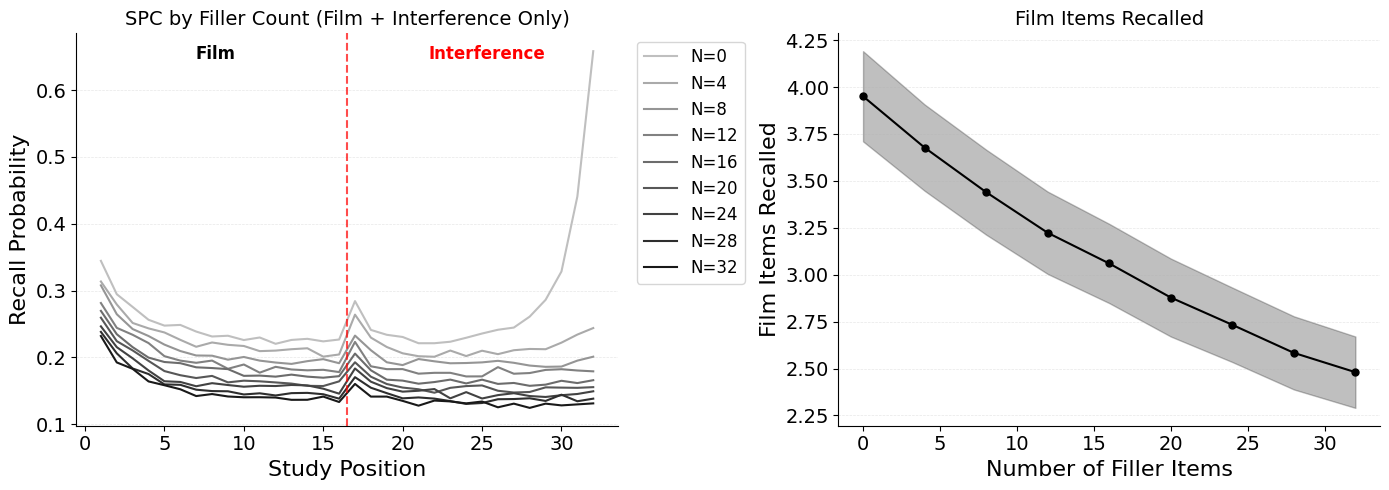

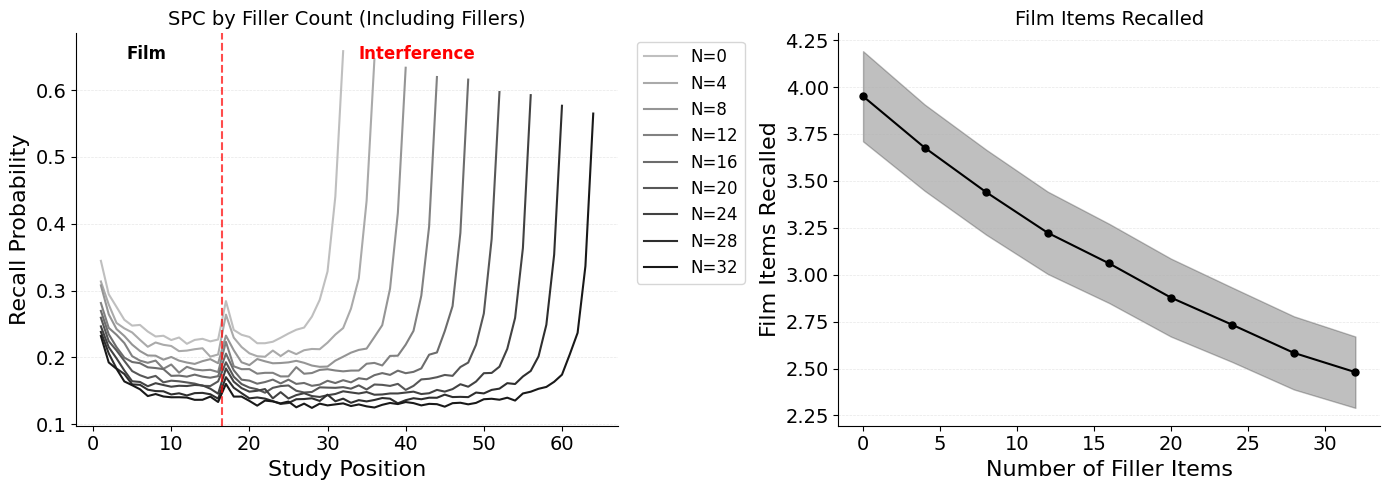

In [10]:
labels = [f"N={n}" for n in filler_count_values]
means, ci_lo, ci_hi = zip(*sweep_filler_stats)

# --- Plot 1: without fillers in SPC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_filler_spcs_without, labels, N_FILM, n_break=N_BREAK_SHOWN, ax=axes[0])
axes[0].set_title("SPC by Filler Count (Film + Interference Only)", fontsize=14)

plot_summary_dv(
    filler_count_values, means, ci_lo, ci_hi,
    xlabel="Number of Filler Items", ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

# --- Plot 2: with fillers in SPC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_presented_filler = [
    N_FILM + N_BREAK_SHOWN + M_DEFAULT + int(n) for n in filler_count_values
]
plot_interference_spc(sweep_filler_spcs_with, labels, N_FILM,
                      n_break=N_BREAK_SHOWN, n_presented=n_presented_filler, ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_MAX, FILLER_PRESENTED_WITH)
axes[0].set_title("SPC by Filler Count (Including Fillers)", fontsize=14)

plot_summary_dv(
    filler_count_values, means, ci_lo, ci_hi,
    xlabel="Number of Filler Items", ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()


### Pre-interference context state: break and reminder

A separate question from interference intensity is *which film items* are most vulnerable.
The answer lies in the context state at the moment competitors are encoded.
Two parameters control this:

- **`reminder_start_drift_scale`** — a scale over each subject's fitted `start_drift_rate`, controlling how much context drifts toward start-of-list before the reminder begins.
This orients context back to the beginning of the film sequence so that the reminder can reinstate context across the full film, rather than starting from the post-break state.

- **`reminder_drift_scale`** — a scale over each subject's fitted `encoding_drift_rate`, controlling how strongly the reminder reinstates film context.
At low scales, the reminder has little effect; at high scales, context is driven back through the film sequence, arriving at a state resembling end-of-film encoding.

The retention interval is modeled by break items encoded between film and reminder — these push context away from the film region via normal encoding.
Together with the start-of-list reinstatement and reminder, they give continuous control over the pre-interference context landscape.
The break drifts context away from film; the start-of-list reinstatement orients back; the reminder drives context through the film sequence.

Importantly, reminders modulate interference *targeting* (which film items are most vulnerable) rather than interference *intensity* (how many film items are recalled) — total film recall is relatively stable across the reminder sweep, but the SPC shape shifts.
This demonstrates that delayed interference does not require a reconsolidation window: the reminder reinstates context overlap, creating the conditions for effective competition (consistent with James et al. 2015).

#### Sweeping start-of-list drift scale

How much does the start-of-list reinstatement before the reminder matter? At low scales, context stays near the post-break state — the reminder begins from wherever the break left context. At high scales, context is driven toward start-of-list before the reminder begins, allowing the reminder to traverse the full film sequence from the beginning. The reminder drift scale is held at its default throughout this sweep.

In [11]:
start_drift_scale_values = np.linspace(0.01, 4.0, 10)
print(f"Start-of-list drift scale sweep values: {start_drift_scale_values.round(2)}")

sweep_start_spcs = []
sweep_start_stats = []

for sds in start_drift_scale_values:
    cached_sds = prepare_all_subjects(
        jnp.arange(n_subjects), params, STD_FILM, STD_BREAK_ALL,
        jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
        jnp.float32(sds), jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
        STD_LIST_LENGTH,
    )
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_sds, rngs_2d,
        STD_INTERF, STD_FILLER,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(1.0), jnp.float32(1.0),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = std_remap(recalls)
    sweep_start_spcs.append(fixed_pres_spc(recalls, STD_PRESENTED))
    sweep_start_stats.append(film_recalled_stats(recalls))

print("Start-of-list drift scale sweep done")


Start-of-list drift scale sweep values: [0.01 0.45 0.9  1.34 1.78 2.23 2.67 3.11 3.56 4.  ]
Start-of-list drift scale sweep done


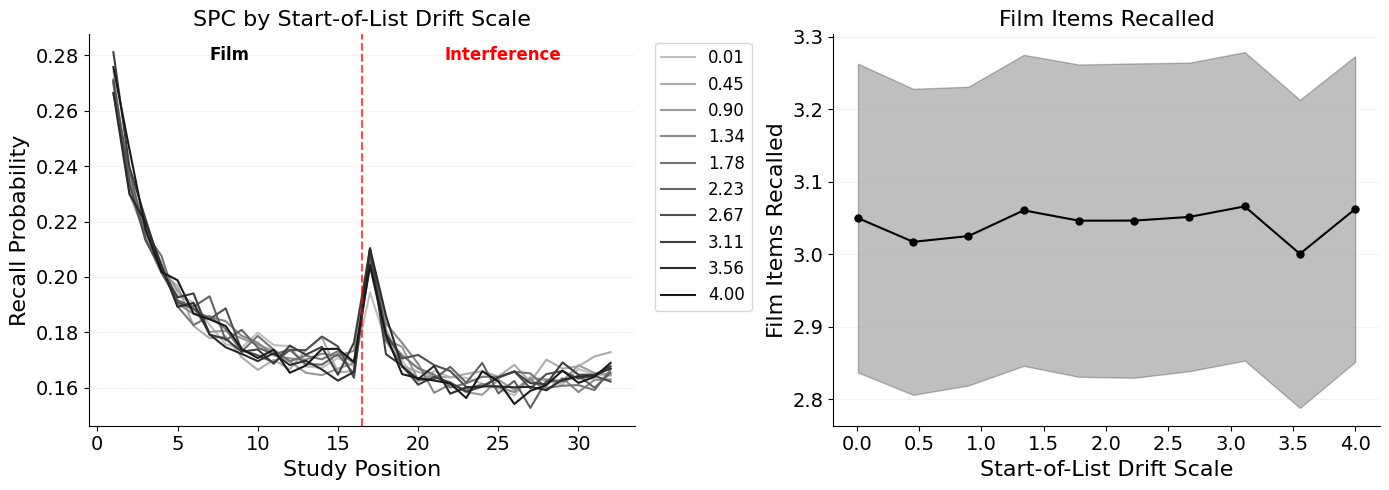

In [12]:
labels = [f"{v:.2f}" for v in start_drift_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_start_spcs, labels, N_FILM, n_break=N_BREAK_SHOWN, ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Start-of-List Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep_start_stats)
plot_summary_dv(
    start_drift_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Start-of-List Drift Scale",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

#### Sweeping reminder drift scale

With the delay drift scale held at its default, this sweep varies how strongly the reminder reinstates film context. At low scales, context barely moves from the post-delay state. At high scales, context drifts rapidly through the film sequence, arriving at a state dominated by the last few film items. Because interference items are subsequently encoded in this context, the reminder drift scale controls how much contextual overlap exists between film and interference items.

The start-of-list drift scale is held at its default throughout this sweep.

In [13]:
reminder_scale_values = np.linspace(0.01, 1.8, 10)
print(f"Reminder drift scale sweep values: {reminder_scale_values.round(3)}")

sweep_rem_spcs = []
sweep_rem_stats = []

for rs in reminder_scale_values:
    cached_rs = prepare_all_subjects(
        jnp.arange(n_subjects), params, STD_FILM, STD_BREAK_ALL,
        jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
        jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE), jnp.float32(rs),
        STD_LIST_LENGTH,
    )
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_rs, rngs_2d,
        STD_INTERF, STD_FILLER,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(1.0), jnp.float32(1.0),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = std_remap(recalls)
    sweep_rem_spcs.append(fixed_pres_spc(recalls, STD_PRESENTED))
    sweep_rem_stats.append(film_recalled_stats(recalls))

print("Reminder sweep done")


Reminder drift scale sweep values: [0.01  0.209 0.408 0.607 0.806 1.004 1.203 1.402 1.601 1.8  ]
Reminder sweep done


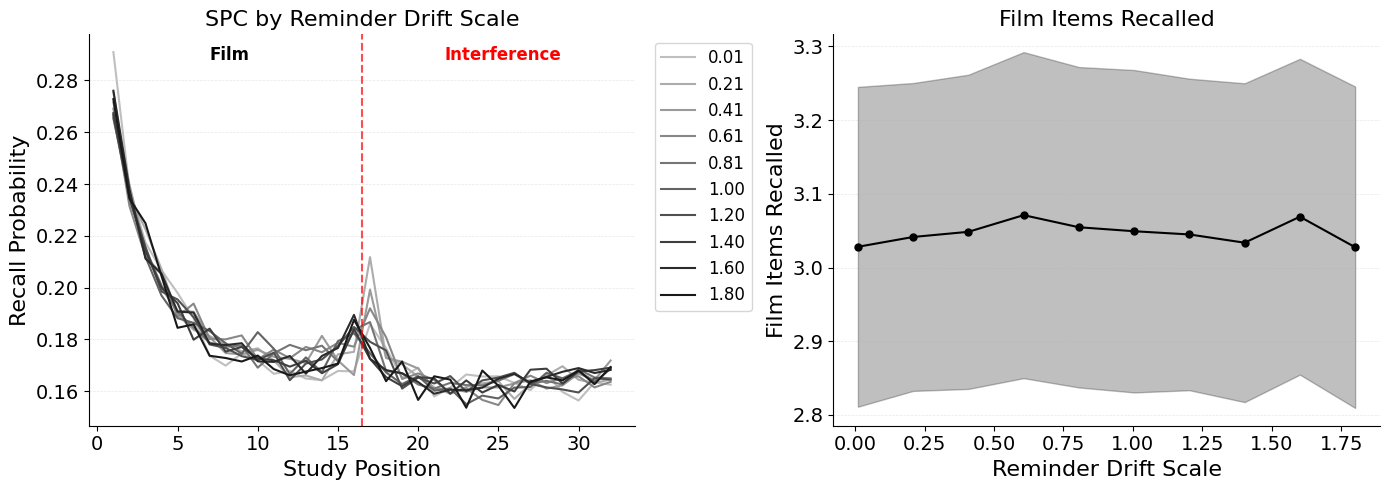

In [14]:
labels = [f"{v:.2f}" for v in reminder_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_rem_spcs, labels, N_FILM, n_break=N_BREAK_SHOWN, ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Reminder Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep_rem_stats)
plot_summary_dv(
    reminder_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Reminder Drift Scale",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

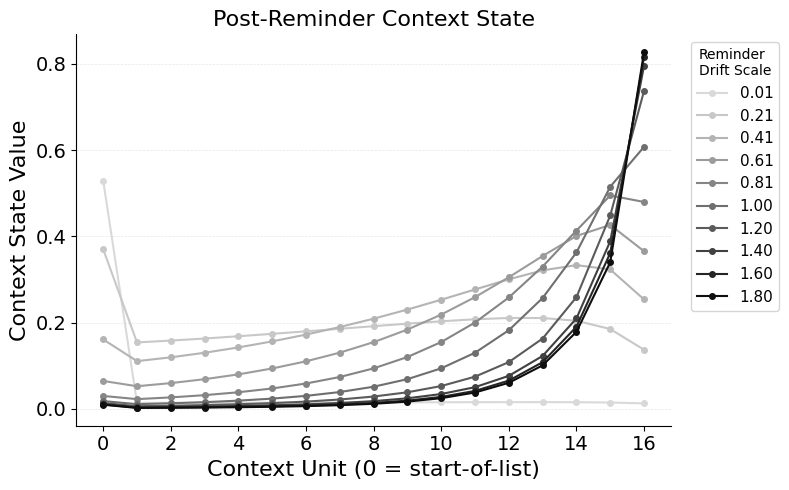

In [15]:
def get_post_reminder_context(subject_idx, params, film_items, break_items,
                              break_drift_scale, break_mcf_scale,
                              reminder_start_drift_scale, reminder_drift_scale,
                              list_length):
    """Context state values at film-item units after reminder phase."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        list_length,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    original_drift = model.encoding_drift_rate
    original_mcf_lr = model._mcf_learning_rate

    # film phase
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # break encoding (models retention interval)
    break_drift = jnp.clip(break_drift_scale * original_drift, 0.0, 1.0)
    model = model.replace(
        encoding_drift_rate=break_drift,
        _mcf_learning_rate=break_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, break_items.size, lambda i, m: m.experience(break_items[i]), model
    )
    model = model.replace(
        encoding_drift_rate=original_drift,
        _mcf_learning_rate=original_mcf_lr,
    )

    # start-of-list reinstatement
    start_drift = jnp.clip(
        reminder_start_drift_scale * model.start_drift_rate, 0.0, 1.0
    )
    model = model.replace(
        context=model.context.integrate(model.context.initial_state, start_drift)
    )

    # reminder
    reminder_drift = jnp.clip(reminder_drift_scale * original_drift, 0.0, 1.0)

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)

    # return context units for film items (indices 1..N_FILM) and start-of-list (index 0)
    return model.context.state[:N_FILM + 1]


_batched_context = jit(
    vmap(get_post_reminder_context,
         in_axes=(0, None, None, None, None, None, None, None, None)),
    static_argnums=(8,),  # list_length must be static for CMR constructor
)
sub_indices = jnp.arange(n_subjects)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(reminder_scale_values)))

for rs, color in zip(reminder_scale_values, colors):
    ctx = _batched_context(
        sub_indices, params, STD_FILM, STD_BREAK_ALL,
        jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
        jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE), jnp.float32(rs),
        STD_LIST_LENGTH,
    )
    mean_ctx = np.asarray(jnp.mean(ctx, axis=0))
    # index 0 = start-of-list, indices 1..N_FILM = film items
    positions = np.arange(0, N_FILM + 1)
    ax.plot(positions, mean_ctx, "o-", color=color, label=f"{rs:.2f}",
            markersize=4, linewidth=1.5)

ax.set_xlabel("Context Unit (0 = start-of-list)", fontsize=16)
ax.set_ylabel("Context State Value", fontsize=16)
ax.set_title("Post-Reminder Context State", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Reminder\nDrift Scale", loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=11)
fig.tight_layout()
plt.show()


#### Context state summary

The film-item context plot reveals what the reminder drift scale does to context before interference begins. At low scales, context stays near the post-break/post-reinstatement state — recall is concentrated at the positions most activated by that state. At high scales, context drifts through the full film sequence and arrives at a state resembling end-of-film context, producing a recency-weighted recall profile across film positions.

Together, the break items, start-of-list reinstatement, and reminder drift scale give continuous control over pre-interference context state. Break items push context away from the film region, modeling the retention interval. The start-of-list reinstatement orients context back to the beginning of the film. The reminder then drives context through the film sequence, restoring contextual overlap and increasing the vulnerability of late-film items. The total number of film items recalled is relatively stable across the reminder sweep: the reminder redistributes *which* film items are recalled but has limited effect on *how many*. This confirms that reminders modulate interference targeting, not interference intensity.

This has implications for the delayed-interference paradigm: delayed interference does not require a reconsolidation window. Instead, the reminder reinstates context overlap, creating the conditions for effective competition between film and interference items.

### Paradigm validation: delayed interference requires the reminder

The break/reminder mechanism raises a key question: is the reminder necessary for delayed interference, or would competitors encoded after a break still impair film recall?
We compare two conditions:

1. **Reminder + competitors** — the standard paradigm: break, start-of-list reinstatement, reminder, then interference items.
2. **No reminder + competitors** — break, then interference items directly (no start-of-list reinstatement, no reminder).

If the reminder is necessary, condition 2 should show little or no interference: after the break, context has drifted far from the film region, so competitors lack the contextual overlap needed to compete at retrieval.
This would be consistent with James et al. (2015), who found that delayed Tetris reduced intrusions only when preceded by a reminder.

In [16]:
# Condition 1: Reminder + competitors (standard paradigm — uses std_cached)
rngs_2d, rng = sweep_rngs(rng)
reminded_recalls_3d = batched_sweep(
    std_cached, rngs_2d,
    STD_INTERF, STD_FILLER,
    jnp.float32(1.0), jnp.float32(1.0),
    jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    jnp.float32(1.0), jnp.float32(1.0),
)
reminded_recalls = reminded_recalls_3d.reshape(-1, reminded_recalls_3d.shape[-1])
reminded_recalls = std_remap(reminded_recalls)
reminded_spc = fixed_pres_spc(reminded_recalls, STD_PRESENTED)
reminded_stats = film_recalled_stats(reminded_recalls)

# Condition 2: No reminder + competitors (both reminder scales = 0)
cached_no_reminder = prepare_all_subjects(
    jnp.arange(n_subjects), params, STD_FILM, STD_BREAK_ALL,
    jnp.float32(DEFAULT_BREAK_DRIFT_SCALE), jnp.float32(DEFAULT_BREAK_MCF_SCALE),
    jnp.float32(0.0), jnp.float32(0.0),
    STD_LIST_LENGTH,
)
rngs_2d, rng = sweep_rngs(rng)
no_reminder_recalls_3d = batched_sweep(
    cached_no_reminder, rngs_2d,
    STD_INTERF, STD_FILLER,
    jnp.float32(1.0), jnp.float32(1.0),
    jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    jnp.float32(1.0), jnp.float32(1.0),
)
no_reminder_recalls = no_reminder_recalls_3d.reshape(-1, no_reminder_recalls_3d.shape[-1])
no_reminder_recalls = std_remap(no_reminder_recalls)
no_reminder_spc = fixed_pres_spc(no_reminder_recalls, STD_PRESENTED)
no_reminder_stats = film_recalled_stats(no_reminder_recalls)

print("Paradigm validation done")
print(f"  Reminder + competitors:    {reminded_stats[0]:.2f} [{reminded_stats[1]:.2f}, {reminded_stats[2]:.2f}]")
print(f"  No reminder + competitors: {no_reminder_stats[0]:.2f} [{no_reminder_stats[1]:.2f}, {no_reminder_stats[2]:.2f}]")


Paradigm validation done
  Reminder + competitors:    3.05 [2.84, 3.27]
  No reminder + competitors: 3.01 [2.79, 3.23]


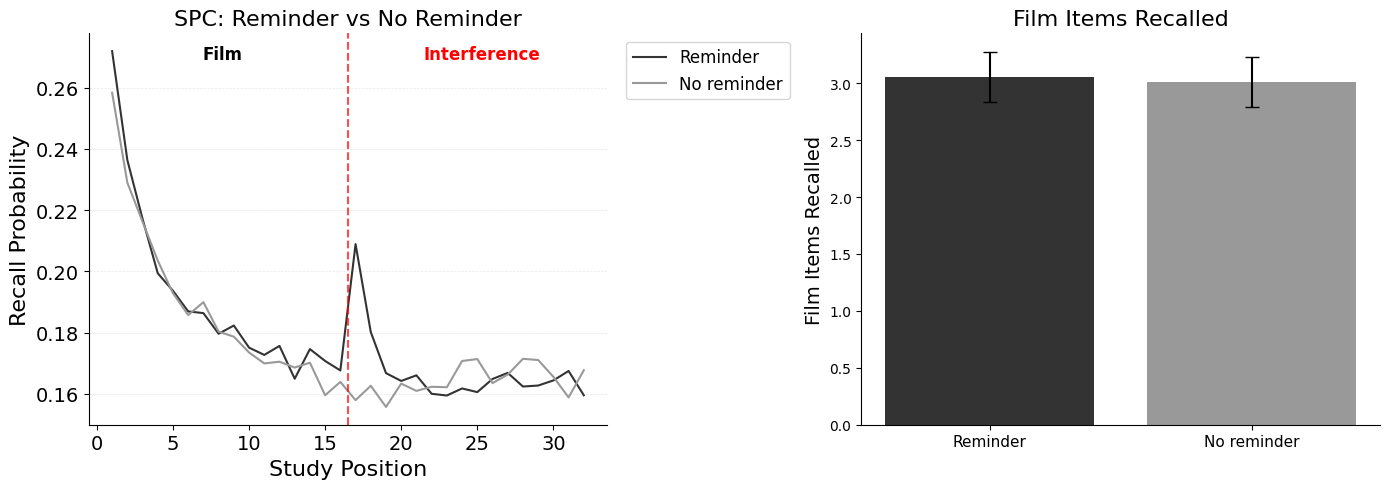

In [17]:
validation_spcs = [reminded_spc, no_reminder_spc]
validation_labels = ["Reminder", "No reminder"]
validation_colors = ["#333333", "#999999"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(validation_spcs, validation_labels, N_FILM,
                      n_break=N_BREAK_SHOWN, colors=validation_colors, ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC: Reminder vs No Reminder", fontsize=16)

# Bar chart
conditions = validation_labels
means = [reminded_stats[0], no_reminder_stats[0]]
errs = [reminded_stats[0] - reminded_stats[1], no_reminder_stats[0] - no_reminder_stats[1]]
x_pos = np.arange(len(conditions))
axes[1].bar(x_pos, means, yerr=errs, capsize=5, color=validation_colors)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(conditions, fontsize=11)
axes[1].set_ylabel("Film Items Recalled", fontsize=14)
axes[1].set_title("Film Items Recalled", fontsize=16)
for loc in ("top", "right"):
    axes[1].spines[loc].set_visible(False)

plt.tight_layout()
plt.show()

### Baseline SPC

With all calibration parameters set, this is the reference condition for subsequent simulations.
All 16 competitors are present with MCF scale = 1.0 — each interference item's MCF learning rate equals what it would receive as an ordinary study item at that position in the primacy gradient.
The default delay and reminder settings are applied.

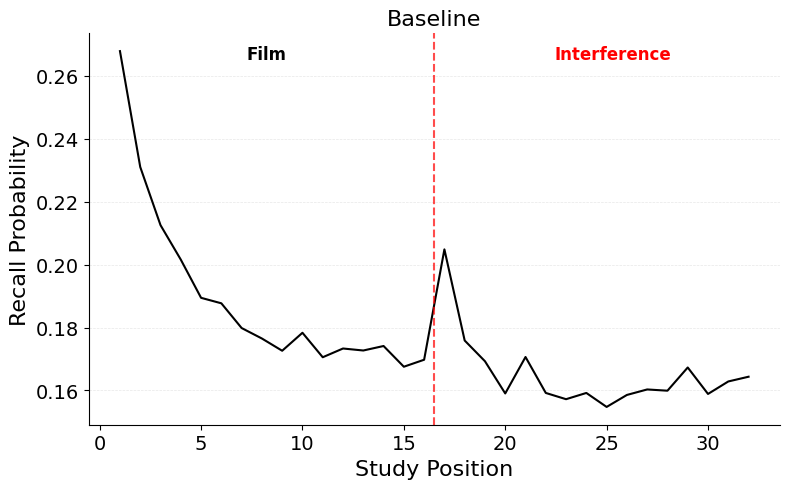

Film items recalled: 3.03 [2.81, 3.24]


In [18]:
rngs_2d, rng = sweep_rngs(rng)
baseline_recalls_3d = batched_sweep(
    std_cached, rngs_2d,
    STD_INTERF, STD_FILLER,
    jnp.float32(1.0), jnp.float32(BASELINE_MCF_SCALE),
    jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    jnp.float32(1.0), jnp.float32(1.0),
)
baseline_recalls = baseline_recalls_3d.reshape(-1, baseline_recalls_3d.shape[-1])
baseline_recalls = std_remap(baseline_recalls)
baseline_spc = fixed_pres_spc(baseline_recalls, STD_PRESENTED)
baseline_stats = film_recalled_stats(baseline_recalls)

fig, ax = plt.subplots(figsize=(8, 5))
plot_interference_spc([baseline_spc], ["Baseline"], N_FILM,
                      n_break=N_BREAK_SHOWN, colors=["black"], ax=ax)
add_filler_boundary(ax, M_DEFAULT, N_FILLER_DEFAULT, STD_PRESENTED)
ax.set_title("Baseline", fontsize=16)
ax.get_legend().remove()
fig.tight_layout()
plt.show()

mu, lo, hi = baseline_stats
print(f"Film items recalled: {mu:.2f} [{lo:.2f}, {hi:.2f}]")


## Sim 1: Interference intensifiers

Having established the paradigm, what encoding-phase factors determine interference intensity?
Three candidates arise from CMR's architecture:

1. **Interference MCF encoding strength** — how strongly competitors are bound into M\_CF.
Stronger associations mean higher retrieval support for competitors, diverting probability mass away from film items during competitive recall.

2. **Interference encoding drift rate** — how much temporal context drifts during the interference phase.
Low drift keeps competitors in film-adjacent context; high drift pushes them into a distant region.

3. **Competitor count** — the sheer number of interfering items.
More competitors mean more total competition, but with a caveat: later competitors accumulate more contextual drift from the film region, so each additional competitor produces diminishing returns.

Each is swept in isolation, holding the other two at their default values.

### Sweeping interference MCF learning rate

The first encoding-phase intensifier is encoding strength in the context-to-item association matrix (M\_CF).
During film encoding, the MCF learning rate follows the fitted primacy gradient — high at position 1, decaying toward 1.0 by position 16.
During the interference phase, each competitor's MCF learning rate is a scale factor times what the primacy gradient would assign at that position.
At scale = 0, competitors receive no M\_CF encoding; at scale = 1.0, they are encoded exactly as additional study items; at scale > 1, they are encoded more strongly than normal.

The sweep ranges from 0 to 3.0 in 10 steps.
Each subject uses their own fitted `encoding_drift_rate` during the interference phase, keeping context proximity constant across the sweep.

In [19]:
%%time
mcf_scale_values = np.linspace(0, 3, 10)
sweep1_spcs, sweep1_stats, rng = run_sweep(
    cached_models, rng, mcf_scale_values, 'interference_mcf_scale',
)
print(f"MCF scale sweep done: {mcf_scale_values.round(2)}")

MCF scale sweep done: [0.   0.33 0.67 1.   1.33 1.67 2.   2.33 2.67 3.  ]
CPU times: user 14.2 s, sys: 1.84 s, total: 16.1 s
Wall time: 7 s


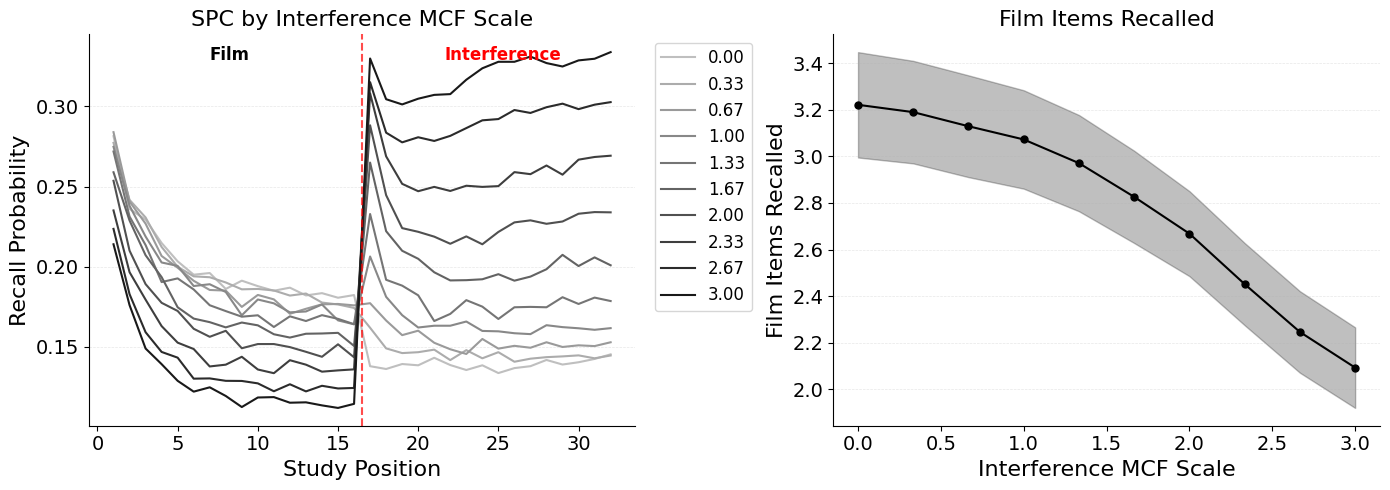

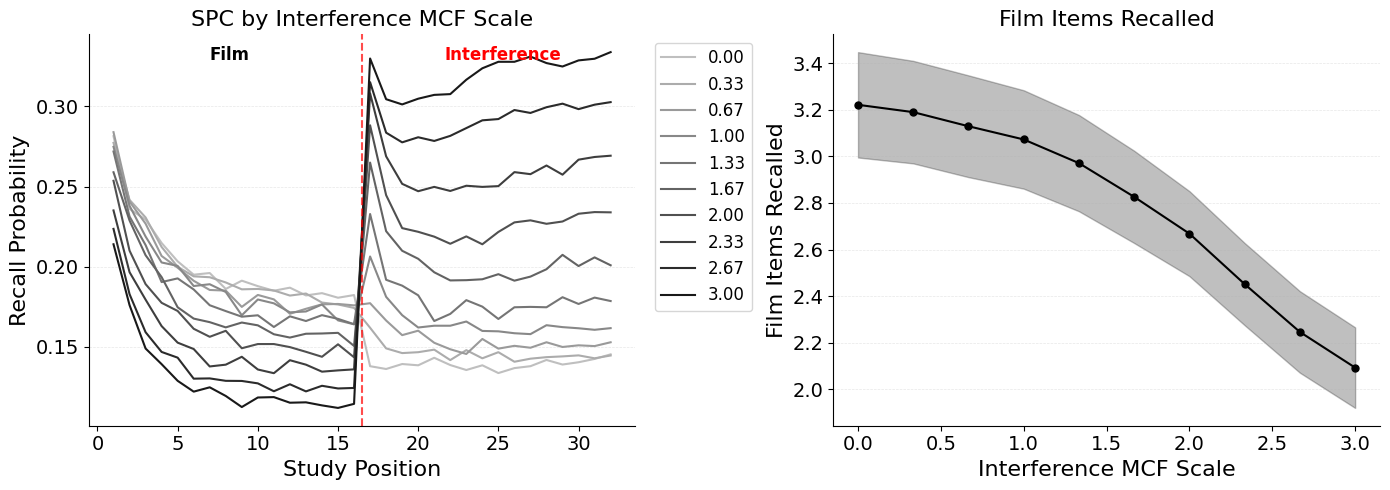

In [20]:
plot_sweep(sweep1_spcs, sweep1_stats, mcf_scale_values,
           xlabel="Interference MCF Scale",
           sweep_title="SPC by Interference MCF Scale")

The left panel shows how the serial position curve changes as MCF scale increases. At scale = 0, competitors receive no encoding and are never recalled — the SPC matches the film-only baseline. As the scale grows, interference items accumulate retrieval support and the Luce choice rule redistributes recall probability away from film items, particularly those at late study positions whose recency advantage is directly contested.

The right panel condenses this into a single dependent variable: mean film items recalled with 95% CI. The monotonic decrease confirms that stronger M\_CF encoding of competitors produces more interference — the first of our three intensifiers.

### Sweeping interference encoding drift rate

The second intensifier is context proximity between film items and competitors.
The `encoding_drift_rate` parameter controls how much temporal context updates when each item is encoded.
During the film phase, this is the subject's fitted value.
During interference, we scale it by a factor: at scale < 1.0 drift is slower (competitors stay closer to film context); at scale = 1.0 context drifts at the same rate as during film encoding; at scale > 1.0 drift is faster (competitors are pushed further away).

We expect a dose-response curve: low scales produce maximal interference, and increasing scale progressively reduces it, approaching a ceiling where competitors are so contextually distant they barely compete.
We fix the interference MCF scale at 1.0 and sweep the drift scale from 0.2 to 1.6.

In [21]:
%%time
drift_scale_values = np.linspace(0.2, 1.6, 10)
sweep2_spcs, sweep2_stats, rng = run_sweep(
    cached_models, rng, drift_scale_values, 'interference_drift_scale',
)
print(f"Drift scale sweep done: {drift_scale_values.round(2)}")

Drift scale sweep done: [0.2  0.36 0.51 0.67 0.82 0.98 1.13 1.29 1.44 1.6 ]
CPU times: user 14.1 s, sys: 1.74 s, total: 15.8 s
Wall time: 6.87 s


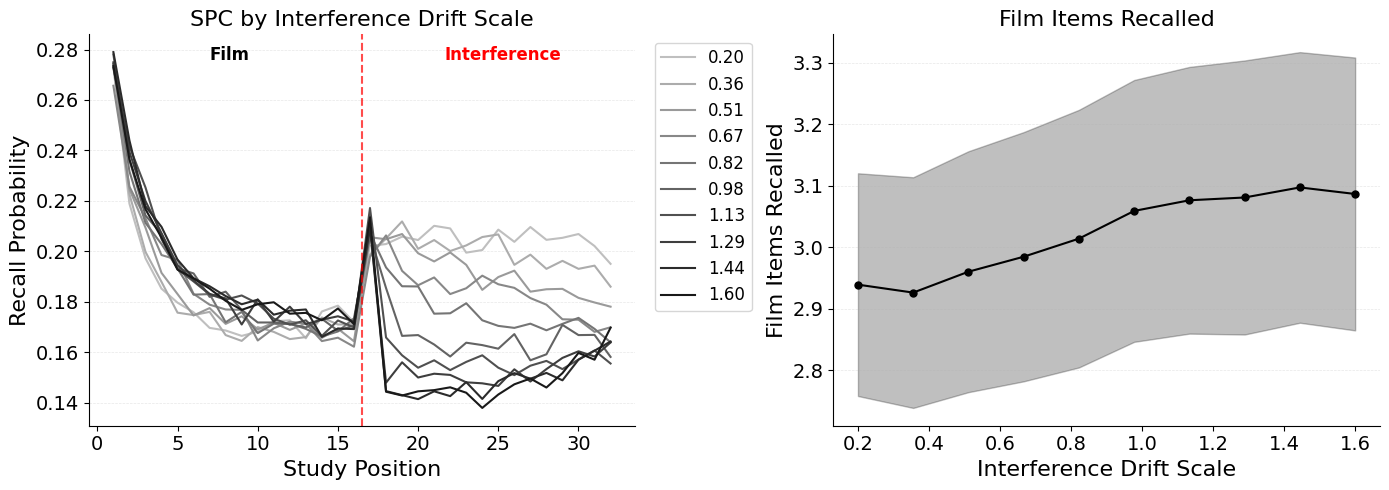

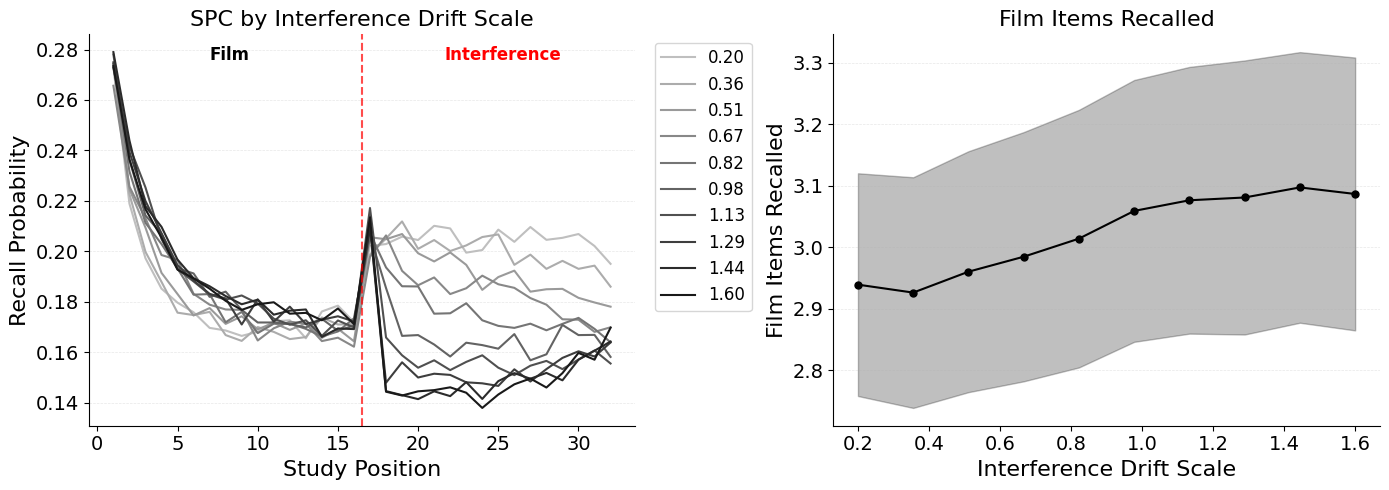

In [22]:
plot_sweep(sweep2_spcs, sweep2_stats, drift_scale_values,
           xlabel="Interference Drift Scale",
           sweep_title="SPC by Interference Drift Scale")

Low drift scales produce the most interference: competitors encoded in film-like context compete strongly at retrieval, suppressing film recall. As the scale increases, competitors are pushed into increasingly distant context states, reducing their activation during retrieval and allowing more film items to be recalled. The curve approaches a ceiling at high scales — beyond a certain point, further increases produce negligible additional relief because the competitors are already contextually irrelevant.

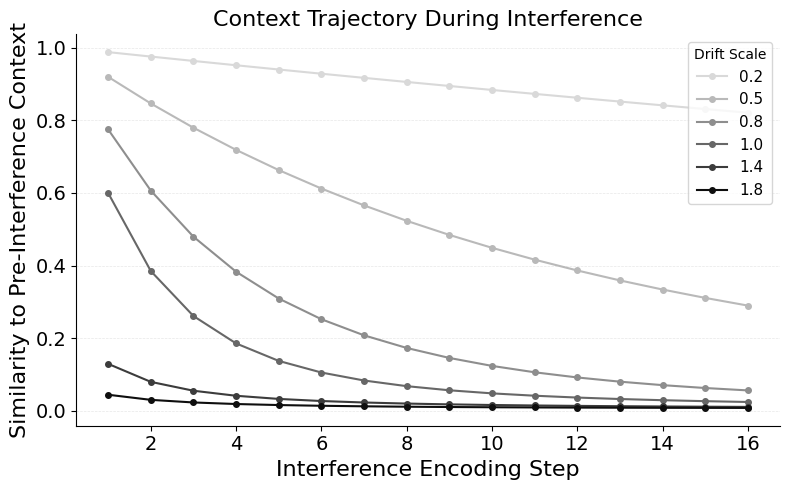

In [23]:
def track_interference_context(
    cached_model, interference_items, drift_scale, mcf_scale
):
    """Similarity to pre-interference context after each encoding step."""
    reference = cached_model.context.state
    original_drift = cached_model.encoding_drift_rate
    original_mcf_lr = cached_model._mcf_learning_rate

    interference_drift = jnp.clip(drift_scale * original_drift, 0.0, 1.0)
    model = cached_model.replace(
        encoding_drift_rate=interference_drift,
        _mcf_learning_rate=mcf_scale * original_mcf_lr,
    )

    def step(m, i):
        m = m.experience(interference_items[i])
        sim = jnp.dot(
            m.context.state / jnp.linalg.norm(m.context.state),
            reference / jnp.linalg.norm(reference),
        )
        return m, sim

    _, trajectory = lax.scan(step, model, jnp.arange(interference_items.shape[0]))
    return trajectory


_batched_trajectory = jit(
    vmap(track_interference_context, in_axes=(0, None, None, None))
)

# Track context trajectory at several drift scale values
traj_drift_values = np.array([0.2, 0.5, 0.8, 1.0, 1.4, 1.8])
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(traj_drift_values)))

for ds, color in zip(traj_drift_values, colors):
    traj = _batched_trajectory(
        std_cached, STD_INTERF,
        jnp.float32(ds), jnp.float32(1.0),
    )
    # Plot all M_DEFAULT steps (STD_INTERF has exactly M_DEFAULT items)
    mean_traj = np.asarray(jnp.mean(traj[:, :M_DEFAULT], axis=0))
    ax.plot(np.arange(1, M_DEFAULT + 1), mean_traj, "o-", color=color,
            label=f"{ds:.1f}", markersize=4, linewidth=1.5)

ax.set_xlabel("Interference Encoding Step", fontsize=16)
ax.set_ylabel("Similarity to Pre-Interference Context", fontsize=16)
ax.set_title("Context Trajectory During Interference", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Drift Scale", loc="upper right", fontsize=11)
fig.tight_layout()
plt.show()


### Sweeping competitor count

The third intensifier is the sheer number of competitors.
With interference drift and MCF scales both fixed at 1.0 (interference items encoded identically to additional study items), adding more competitors should reduce film recall — but with diminishing returns, because later competitors drift further from film context and therefore compete less effectively.

In [24]:
m_values = np.arange(10, 33, 2, dtype=int)
print(f"Competitor count sweep values: {m_values}")

COMP_PRESENTED = (
    N_FILM + N_BREAK_SHOWN + M_MAX
    + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)
)

sweep3_spcs = []
sweep3_stats = []

for m in m_values:
    rngs_2d, rng = sweep_rngs(rng)
    interf_items = make_ext_interf(int(m))
    recalls_3d = batched_sweep(
        ext_cached, rngs_2d,
        interf_items, EXT_FILLER,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(1.0), jnp.float32(1.0),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = ext_remap(recalls, n_interf=M_MAX)
    sweep3_spcs.append(fixed_pres_spc(recalls, COMP_PRESENTED))
    sweep3_stats.append(film_recalled_stats(recalls))

print("Sweep 3 done")


Competitor count sweep values: [10 12 14 16 18 20 22 24 26 28 30 32]
Sweep 3 done


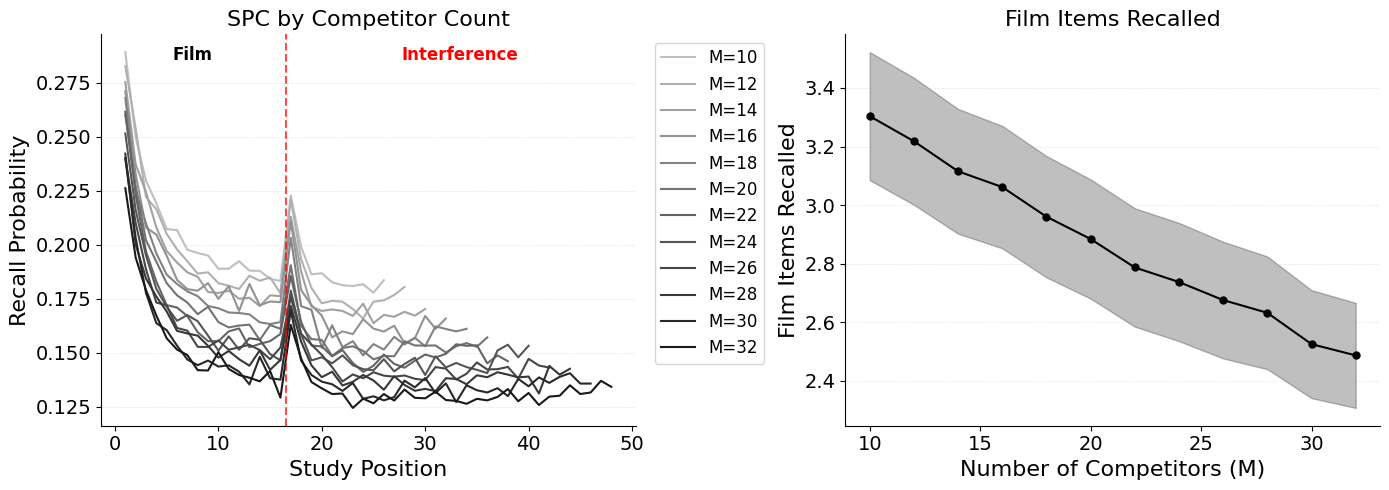

In [25]:
labels = [f"M={m}" for m in m_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_presented_comp = [
    N_FILM + N_BREAK_SHOWN + int(m)
    + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)
    for m in m_values
]
plot_interference_spc(sweep3_spcs, labels, N_FILM,
                      n_break=N_BREAK_SHOWN, n_presented=n_presented_comp, ax=axes[0])
add_filler_boundary(axes[0], M_MAX, N_FILLER_DEFAULT, COMP_PRESENTED)
axes[0].set_title("SPC by Competitor Count", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep3_stats)
plot_summary_dv(
    m_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Competitors (M)",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()


More competitors produce more interference, but with diminishing returns as predicted. The first few competitors — those encoded in context most similar to the film items — have the strongest suppressive effect. Later competitors are encoded after more contextual drift and contribute progressively less interference. The SPC shows the interference effect concentrated at late film positions: recency is eroded first, while primacy is relatively protected by the strong M\_CF encoding at early positions.

This diminishing-returns pattern has an important empirical implication: the *timing* of interference (context proximity) matters more than the *amount* (raw count). A small number of competitors encoded in highly similar context can produce more interference than many competitors encoded after substantial drift.

### Summary

Three manipulations intensify interference from competing events, each operating through a distinct mechanism in the retrieved-context framework:

1. **Interference MCF encoding strength** increases retrieval support for competitors, redistributing probability mass away from film items under the Luce choice rule. The effect is monotonic.

2. **Interference encoding drift rate** controls context proximity. Low scales keep competitors in film-adjacent context; high scales push them into contextually distant states. The effect follows a dose-response curve with a ceiling.

3. **Competitor count** adds more entries into the association matrices, but with diminishing returns: later competitors accumulate more contextual drift. The timing of interference matters more than the raw amount.

**Postdictions**: More engaging interference tasks produce stronger effects (MCF encoding); simply increasing task duration shows diminishing returns (Holmes et al. 2009; James et al. 2015).

**Predictions**: Interference is primarily driven by MCF encoding strength and context proximity, not count alone. Sequential encoding naturally produces a recency gradient — late-film items are disproportionately suppressed because they share the most temporal context with competitors.

In [26]:
print("Default parameters (non-swept variables):")
print(f"  shared_support scale:         {FITTED_PARAM_SCALES['shared_support']}")
print("  Interference MCF scale:       1.0")
print("  Interference drift scale:     1.0")
print(f"  Break count (default):        {N_BREAK_DEFAULT}")
print(f"  Break drift scale:            {DEFAULT_BREAK_DRIFT_SCALE}")
print(f"  Break MCF scale:              {DEFAULT_BREAK_MCF_SCALE}")
print(f"  Reminder start drift scale:   {DEFAULT_REMINDER_START_DRIFT_SCALE}")
print(f"  Reminder drift scale:         {DEFAULT_REMINDER_DRIFT_SCALE}")
print("  Filler drift scale:           1.0")
print("  Filler MCF scale:             1.0")
print(f"  Competitor count (M):         {M_DEFAULT}")
print(f"  Filler count (default):       {N_FILLER_DEFAULT}")
print(f"  Max break items (sweep):      {N_BREAK_MAX}")
print(f"  Max fillers (sweep):          {N_FILLER_MAX}")
print(f"  Max competitors (sweep):      {M_MAX}")
print(f"  Standard list length:         {STD_LIST_LENGTH}")
print(f"  Extended list length:         {EXT_LIST_LENGTH}")
print(f"  Max recall steps:             {MAX_RECALL}")
print(f"  Subjects:                     {n_subjects}")
print(f"  Replications per sweep:       {EXPERIMENT_COUNT}")


Default parameters (non-swept variables):
  shared_support scale:         1.0
  Interference MCF scale:       1.0
  Interference drift scale:     1.0
  Break count (default):        16
  Break drift scale:            1.0
  Break MCF scale:              1.0
  Reminder start drift scale:   4.0
  Reminder drift scale:         0.3
  Filler drift scale:           1.0
  Filler MCF scale:             1.0
  Competitor count (M):         16
  Filler count (default):       16
  Max break items (sweep):      32
  Max fillers (sweep):          32
  Max competitors (sweep):      32
  Standard list length:         64
  Extended list length:         80
  Max recall steps:             48
  Subjects:                     126
  Replications per sweep:       100


## Sim 2: Arousal-specific interference

Temporal context isn't the only source of overlap between film and interference items.
If film items are emotionally arousing, high-arousal interference items share arousal context features — creating competition that operates independently of temporal position.
This simulation uses eCMR, which adds an emotional context channel to CMR.
When all items are neutral, eCMR collapses to CMR; when high-arousal items are present, the emotional channel creates additional context overlap.

*Implementation pending.*

## Sim 3: Retrieval control

Given that interference acts at encoding, what retrieval-phase mechanisms modulate vulnerability?
Two control mechanisms in CMR provide graded protection for intentional recall:

1. **Starting-context reinstatement** (`start_drift_rate`) — at test onset, context is drifted toward the pre-experimental state, biasing retrieval away from recently encoded interference items. Scaling this up makes the retrieval probe less similar to the interference region and more similar to the film region.

2. **Choice sensitivity** (`mcf_sensitivity` / tau) — the exponent in the power-scale transformation of M\_CF activations. Higher tau sharpens the Luce choice rule, concentrating retrieval probability on strongly activated items (film items with strong M\_CF associations) and suppressing weakly activated competitors.

Each is swept in isolation, then a 2×2 summary examines their interaction.

### Sweeping start\_drift\_rate scale

At test onset, `start_retrieving()` integrates the pre-experimental context state with drift rate `start_drift_rate`.
Scaling this up biases the retrieval probe away from the interference region.
At very high scales, context is dominated by pre-experimental features, making interference items contextually invisible.
We sweep the scale from 0.2 to 3.0 while holding tau at its fitted value.

In [27]:
%%time
start_drift_scale_values_sim3 = np.linspace(0.2, 3.0, 10)
sweep_sds_spcs, sweep_sds_stats, rng = run_sweep(
    cached_models, rng, start_drift_scale_values_sim3, 'start_drift_scale',
)
print(f"Start drift scale sweep done: {start_drift_scale_values_sim3.round(2)}")

Start drift scale sweep done: [0.2  0.51 0.82 1.13 1.44 1.76 2.07 2.38 2.69 3.  ]
CPU times: user 14.2 s, sys: 1.73 s, total: 15.9 s
Wall time: 6.87 s


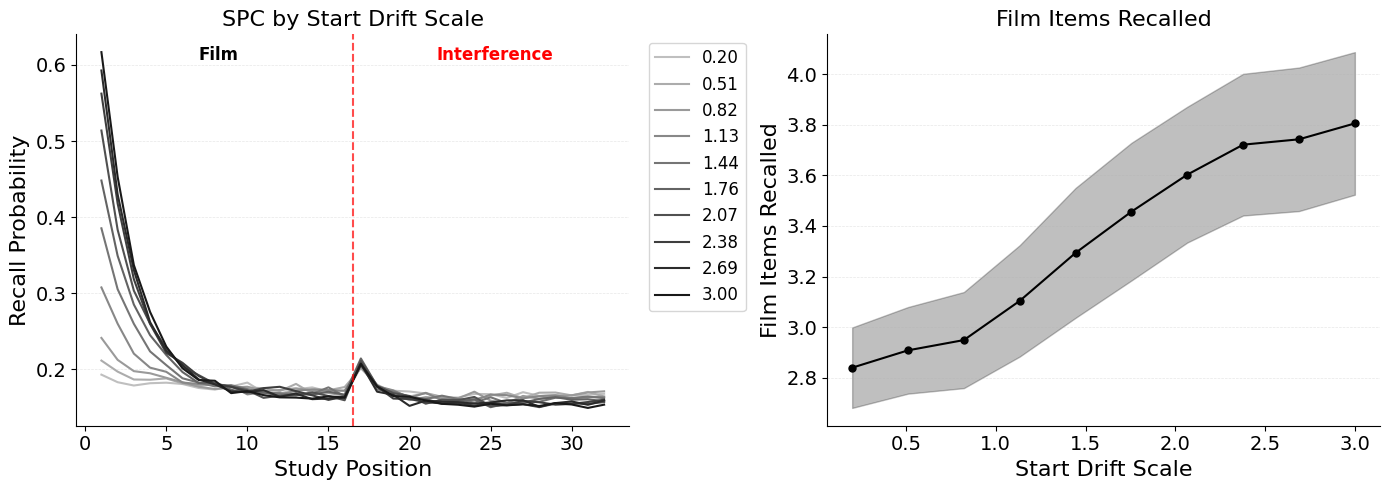

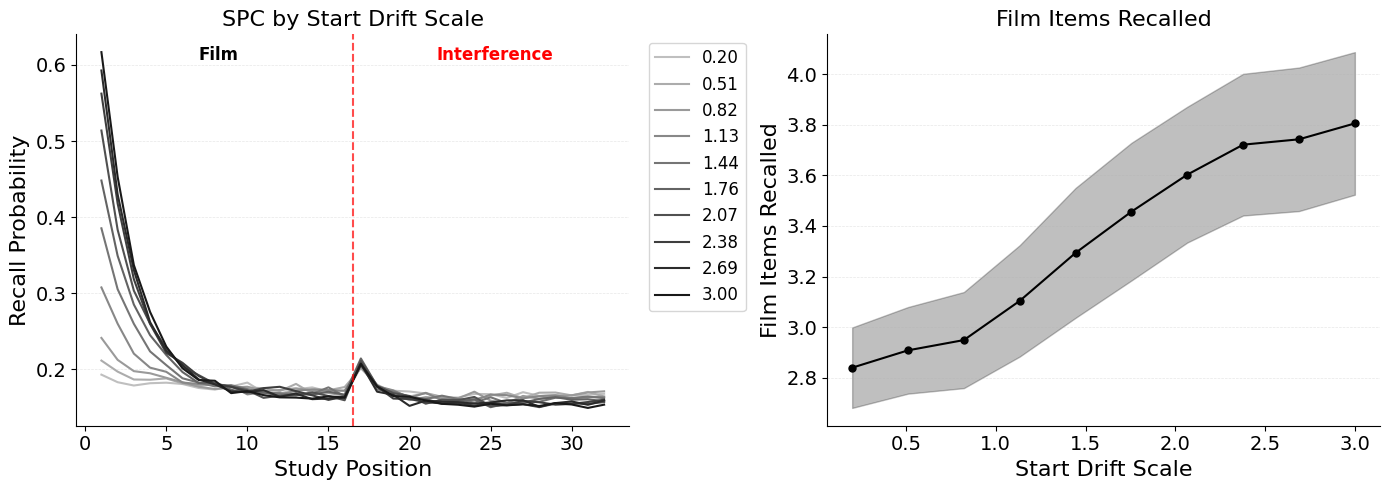

In [28]:
plot_sweep(sweep_sds_spcs, sweep_sds_stats, start_drift_scale_values_sim3,
           xlabel="Start Drift Scale",
           sweep_title="SPC by Start Drift Scale")

### Sweeping choice sensitivity (tau) scale

Choice sensitivity (tau) is the exponent applied to M\_CF activations before the Luce choice rule.
At low tau, all items with nonzero activation compete roughly equally — interference items dilute film recall.
At high tau, the choice rule sharpens: retrieval probability concentrates on the most strongly activated items, suppressing weakly activated competitors.

For tau's protective effect to be visible, the retrieval probe must already be biased away from the interference region — otherwise sharpening the choice rule can actually *help* interference items win.
We therefore hold `start_drift_scale` at an elevated value (2.0) and sweep tau from 0.2 to 3.0.

In [29]:
%%time
TAU_SWEEP_START_DRIFT_SCALE = 2.0
tau_scale_values = np.linspace(0.2, 3.0, 10)
sweep_tau_spcs, sweep_tau_stats, rng = run_sweep(
    cached_models, rng, tau_scale_values, 'tau_scale',
    overrides={'start_drift_scale': jnp.float32(TAU_SWEEP_START_DRIFT_SCALE)},
)
print(f"Tau scale sweep done (start_drift_scale={TAU_SWEEP_START_DRIFT_SCALE}): {tau_scale_values.round(2)}")

Tau scale sweep done (start_drift_scale=2.0): [0.2  0.51 0.82 1.13 1.44 1.76 2.07 2.38 2.69 3.  ]
CPU times: user 14.1 s, sys: 1.77 s, total: 15.9 s
Wall time: 6.83 s


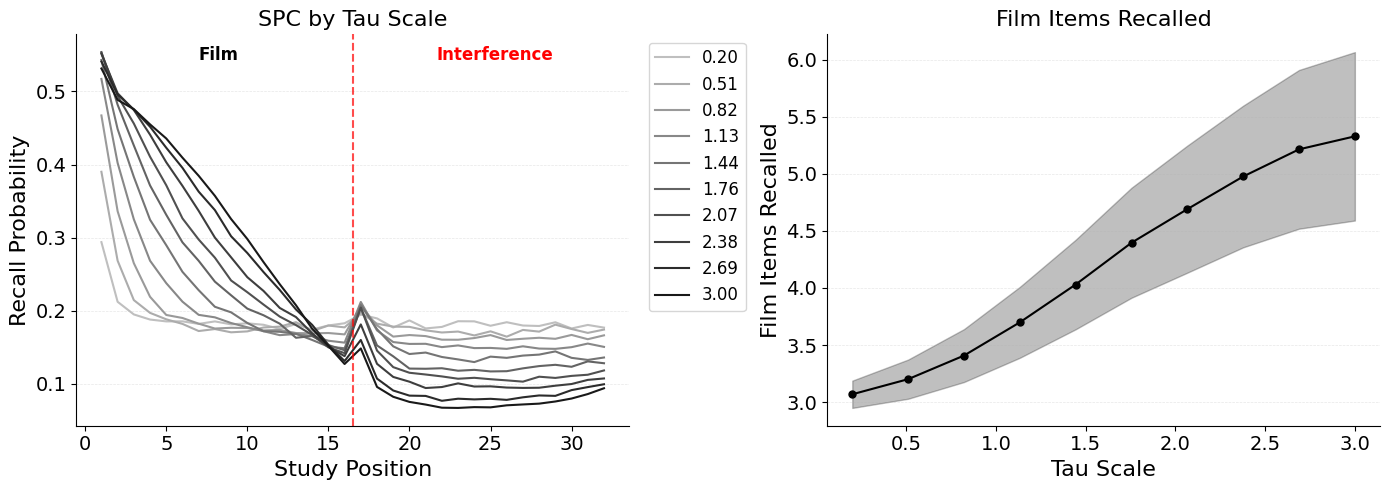

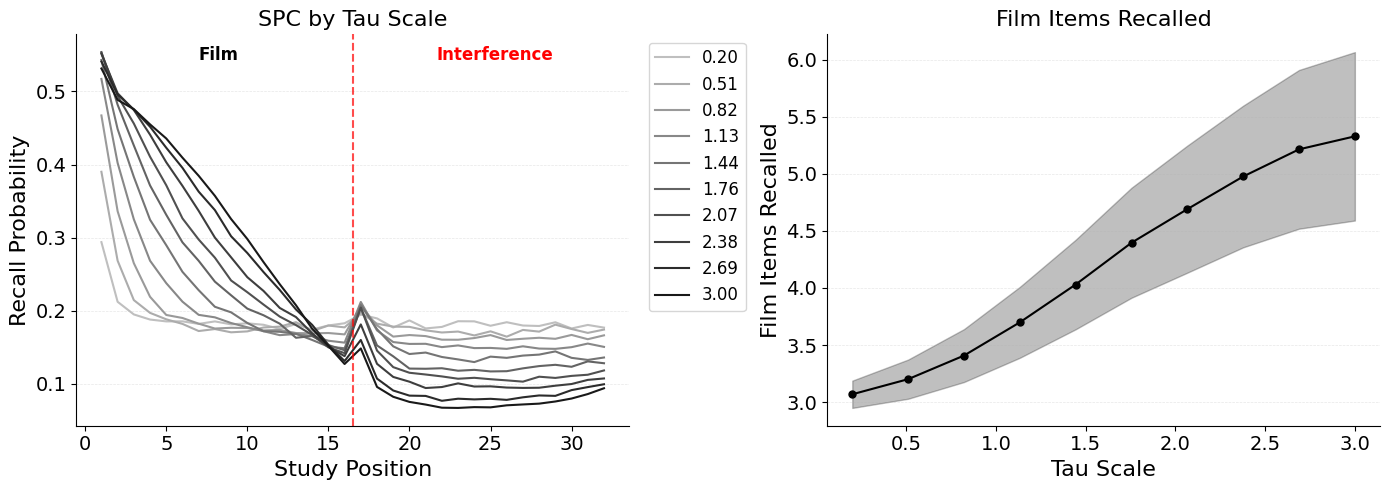

In [30]:
plot_sweep(sweep_tau_spcs, sweep_tau_stats, tau_scale_values,
           xlabel="Tau Scale",
           sweep_title="SPC by Tau Scale")

### Interaction: start drift × tau

Do the two retrieval-control mechanisms interact?
A 2×2 comparison crosses low and high values of each scale factor.
If tau adds value beyond start drift alone, the high-tau conditions should show additional film recall recovery even when start drift is already elevated.

In [31]:
# 2x2: low/high start_drift x low/high tau
sds_lo, sds_hi = 0.5, 2.5
tau_lo, tau_hi = 0.5, 2.0

interaction_conditions = [
    ("Low start / Low tau", sds_lo, tau_lo),
    ("Low start / High tau", sds_lo, tau_hi),
    ("High start / Low tau", sds_hi, tau_lo),
    ("High start / High tau", sds_hi, tau_hi),
]

interaction_spcs = []
interaction_stats = []

for label, sds, ts in interaction_conditions:
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        std_cached, rngs_2d,
        STD_INTERF, STD_FILLER,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
        jnp.float32(sds), jnp.float32(ts),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = std_remap(recalls)
    interaction_spcs.append(fixed_pres_spc(recalls, STD_PRESENTED))
    interaction_stats.append(film_recalled_stats(recalls))

print("Interaction sweep done")


Interaction sweep done


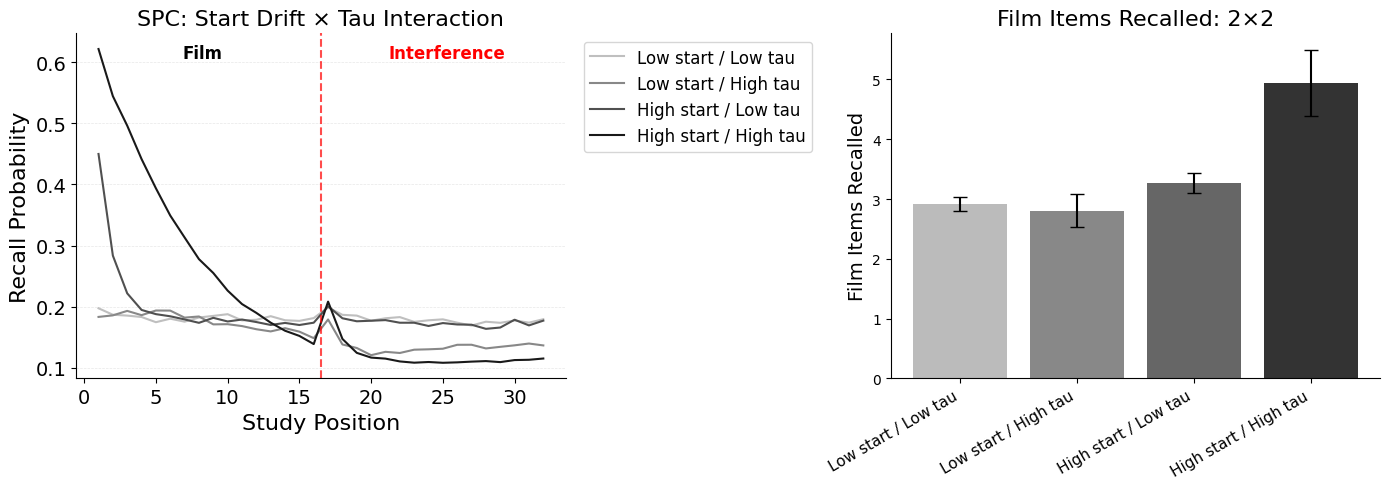

Condition                         Mean            95% CI
--------------------------------------------------------
Low start / Low tau               2.91  [  2.79,   3.04]
Low start / High tau              2.81  [  2.53,   3.08]
High start / Low tau              3.27  [  3.10,   3.44]
High start / High tau             4.94  [  4.38,   5.50]


In [32]:
labels = [c[0] for c in interaction_conditions]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(interaction_spcs, labels, N_FILM, n_break=N_BREAK_SHOWN, ax=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC: Start Drift × Tau Interaction", fontsize=16)

# Bar chart for 2x2
means, ci_lo, ci_hi = zip(*interaction_stats)
x_pos = np.arange(len(labels))
errs = [m - lo for m, lo in zip(means, ci_lo)]
axes[1].bar(x_pos, means, yerr=errs, capsize=5, color=["#bbb", "#888", "#666", "#333"])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=30, ha="right", fontsize=11)
axes[1].set_ylabel("Film Items Recalled", fontsize=14)
axes[1].set_title("Film Items Recalled: 2×2", fontsize=16)
for loc in ("top", "right"):
    axes[1].spines[loc].set_visible(False)

plt.tight_layout()
plt.show()

# Print table
print(f"{'Condition':<30s}  {'Mean':>6s}  {'95% CI':>16s}")
print("-" * 56)
for label, (mu, lo, hi) in zip(labels, interaction_stats):
    print(f"{label:<30s}  {mu:6.2f}  [{lo:6.2f}, {hi:6.2f}]")

### Summary

Two retrieval-phase mechanisms modulate vulnerability to context-overlap interference:

1. **Starting-context reinstatement** biases the retrieval probe away from the interference region. At high scales, this shifts the SPC toward early-list items and progressively reduces competition from interference items.

2. **Choice sensitivity (tau)** sharpens the Luce choice rule, concentrating retrieval probability on strongly activated items. Film items with strong primacy-boosted M\_CF associations are protected; weakly activated competitors are suppressed.

Together, these mechanisms provide graded retrieval-control immunity. The 2×2 comparison shows whether their effects are additive or interactive — whether tau adds protection beyond what start-drift reinstatement achieves alone.

**Postdiction**: Intentional free recall is sometimes spared despite using context-to-item retrieval (Lau-Zhu et al. 2019), because retrieval-control mechanisms compensate for encoding-phase interference. Tasks with lower retrieval control (e.g. involuntary intrusions, cued paradigms) remain vulnerable.

## Sim 4: Cues at test

Some paradigms (VIT-style) present film cues during the test phase.
Film cues reinstate trauma context via item-to-context retrieval, partially overriding the retrieval-control mechanisms from Sim 3.
This explains inconsistency in the selective interference literature across cued vs uncued paradigms.

*Implementation pending.*

## Sim 5: Mode dissociation

The context-binding account predicts a specific architectural dissociation.
Free recall uses context-to-item retrieval (M\_CF), which is directly affected by competitor encoding.
Recognition uses item-to-context retrieval (M\_FC) — probing with a test item retrieves its associated context, and the dot product with current context gives the recognition signal.
Because items are orthogonal, encoding competitors only modifies competitor rows of M\_FC; probing with a film item returns the same context vector regardless, making recognition structurally immune.

*Implementation pending.*

## General discussion

*To be written after all simulations are implemented.*